In [2]:
# ===== Install (Colab) =====
!pip -q install -U transformers accelerate datasets sentencepiece

In [3]:
import os
import math
import datetime
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import rc

# ===== Plotting setup (unchanged) =====
%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = (12, 8)

# ===== Reproducibility =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
_ = torch.manual_seed(RANDOM_SEED)

In [4]:
!gdown --id 1OlcvGWReJMuyYQuOZm149vHWwPtlboR6 --output train.csv
!gdown --id 1Oi5cRlTybuIF2Fl5Bfsr-KkqrXrdt77w --output valid.csv
!gdown --id 1ep9H6-HvhB4utJRLVcLzieWNUSG3P_uF --output test.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1OlcvGWReJMuyYQuOZm149vHWwPtlboR6
To: /content/train.csv
100% 799k/799k [00:00<00:00, 90.4MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Oi5cRlTybuIF2Fl5Bfsr-KkqrXrdt77w
To: /content/valid.csv
100% 43.3k/43.3k [00:00<00:00, 49.6MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.goog

In [5]:
train = pd.read_csv("train.csv")
valid = pd.read_csv("valid.csv")
test  = pd.read_csv("test.csv")

display(train.head())
print(len(train), len(valid), len(test))

,text,intent
0,listen to westbam alumb allergic on google music,PlayMusic
1,add step to me to the 50 clásicos playlist,AddToPlaylist
2,i give this current textbook a rating value of...,RateBook
3,play the song little robin redbreast,PlayMusic
4,please add iris dement to my playlist this is ...,AddToPlaylist


13084 700 700


In [6]:
# ===== Labels mapping =====
labels = sorted(train["intent"].unique().tolist())
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}
num_labels = len(labels)
print("num_labels:", num_labels)

# ===== Tokenizer/Model selection =====
model_name = "bert-base-uncased"  # choose multilingual if needed

tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

num_labels: 7


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# ===== Dataset =====
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=64):
        self.texts = df["text"].astype(str).tolist()
        self.labels = [label2id[y] for y in df["intent"].tolist()]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}  # input_ids, attention_mask, token_type_ids (if present)
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ===== DataLoaders =====
max_len = 64
batch_size_train = 32
batch_size_eval  = 64

train_ds = IntentDataset(train, tokenizer, label2id, max_len=max_len)
valid_ds = IntentDataset(valid, tokenizer, label2id, max_len=max_len)
test_ds  = IntentDataset(test,  tokenizer, label2id, max_len=max_len)

train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size_eval, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size_eval,  shuffle=False)


In [8]:
# ===== Device =====
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print("Device:", device)

model.to(device)

# ===== Optimizer & Scheduler =====
from torch.optim import AdamW

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)
num_training_steps = epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)


Device: cpu


In [9]:
# ===== Training loop =====
best_val_acc = 0.0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)  # returns loss, logits
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [valid]"):
            labels = batch['labels']
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = logits.argmax(dim=-1).cpu()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total if total > 0 else 0.0
    print(f"Epoch {epoch+1}: train_loss={running_loss/len(train_loader):.4f} val_acc={val_acc:.4f}")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('checkpoint', exist_ok=True)
        model.save_pretrained('checkpoint')
        tokenizer.save_pretrained('checkpoint')
        print("Saved best checkpoint.")


Epoch 1/3 [valid]: 100%|██████████| 11/11 [02:15<00:00, 12.36s/it]


Epoch 1: train_loss=0.5166 val_acc=0.9900
Saved best checkpoint.


Epoch 2/3 [valid]: 100%|██████████| 11/11 [02:16<00:00, 12.44s/it]


Epoch 2: train_loss=0.0379 val_acc=0.9929
Saved best checkpoint.


Epoch 3/3 [valid]: 100%|██████████| 11/11 [02:15<00:00, 12.30s/it]

Epoch 3: train_loss=0.0210 val_acc=0.9900


Test: 100%|██████████| 11/11 [02:20<00:00, 12.75s/it]


                      precision    recall  f1-score   support

       AddToPlaylist       1.00      1.00      1.00       124
      BookRestaurant       0.99      1.00      0.99        92
          GetWeather       1.00      0.99      1.00       104
           PlayMusic       0.98      0.98      0.98        86
            RateBook       1.00      1.00      1.00        80
  SearchCreativeWork       0.92      0.98      0.95       107
SearchScreeningEvent       1.00      0.93      0.97       107

            accuracy                           0.98       700
           macro avg       0.98      0.98      0.98       700
        weighted avg       0.98      0.98      0.98       700

[[124   0   0   0   0   0   0]
 [  0  92   0   0   0   0   0]
 [  0   1 103   0   0   0   0]
 [  0   0   0  84   0   2   0]
 [  0   0   0   0  80   0   0]
 [  0   0   0   2   0 105   0]
 [  0   0   0   0   0   7 100]]


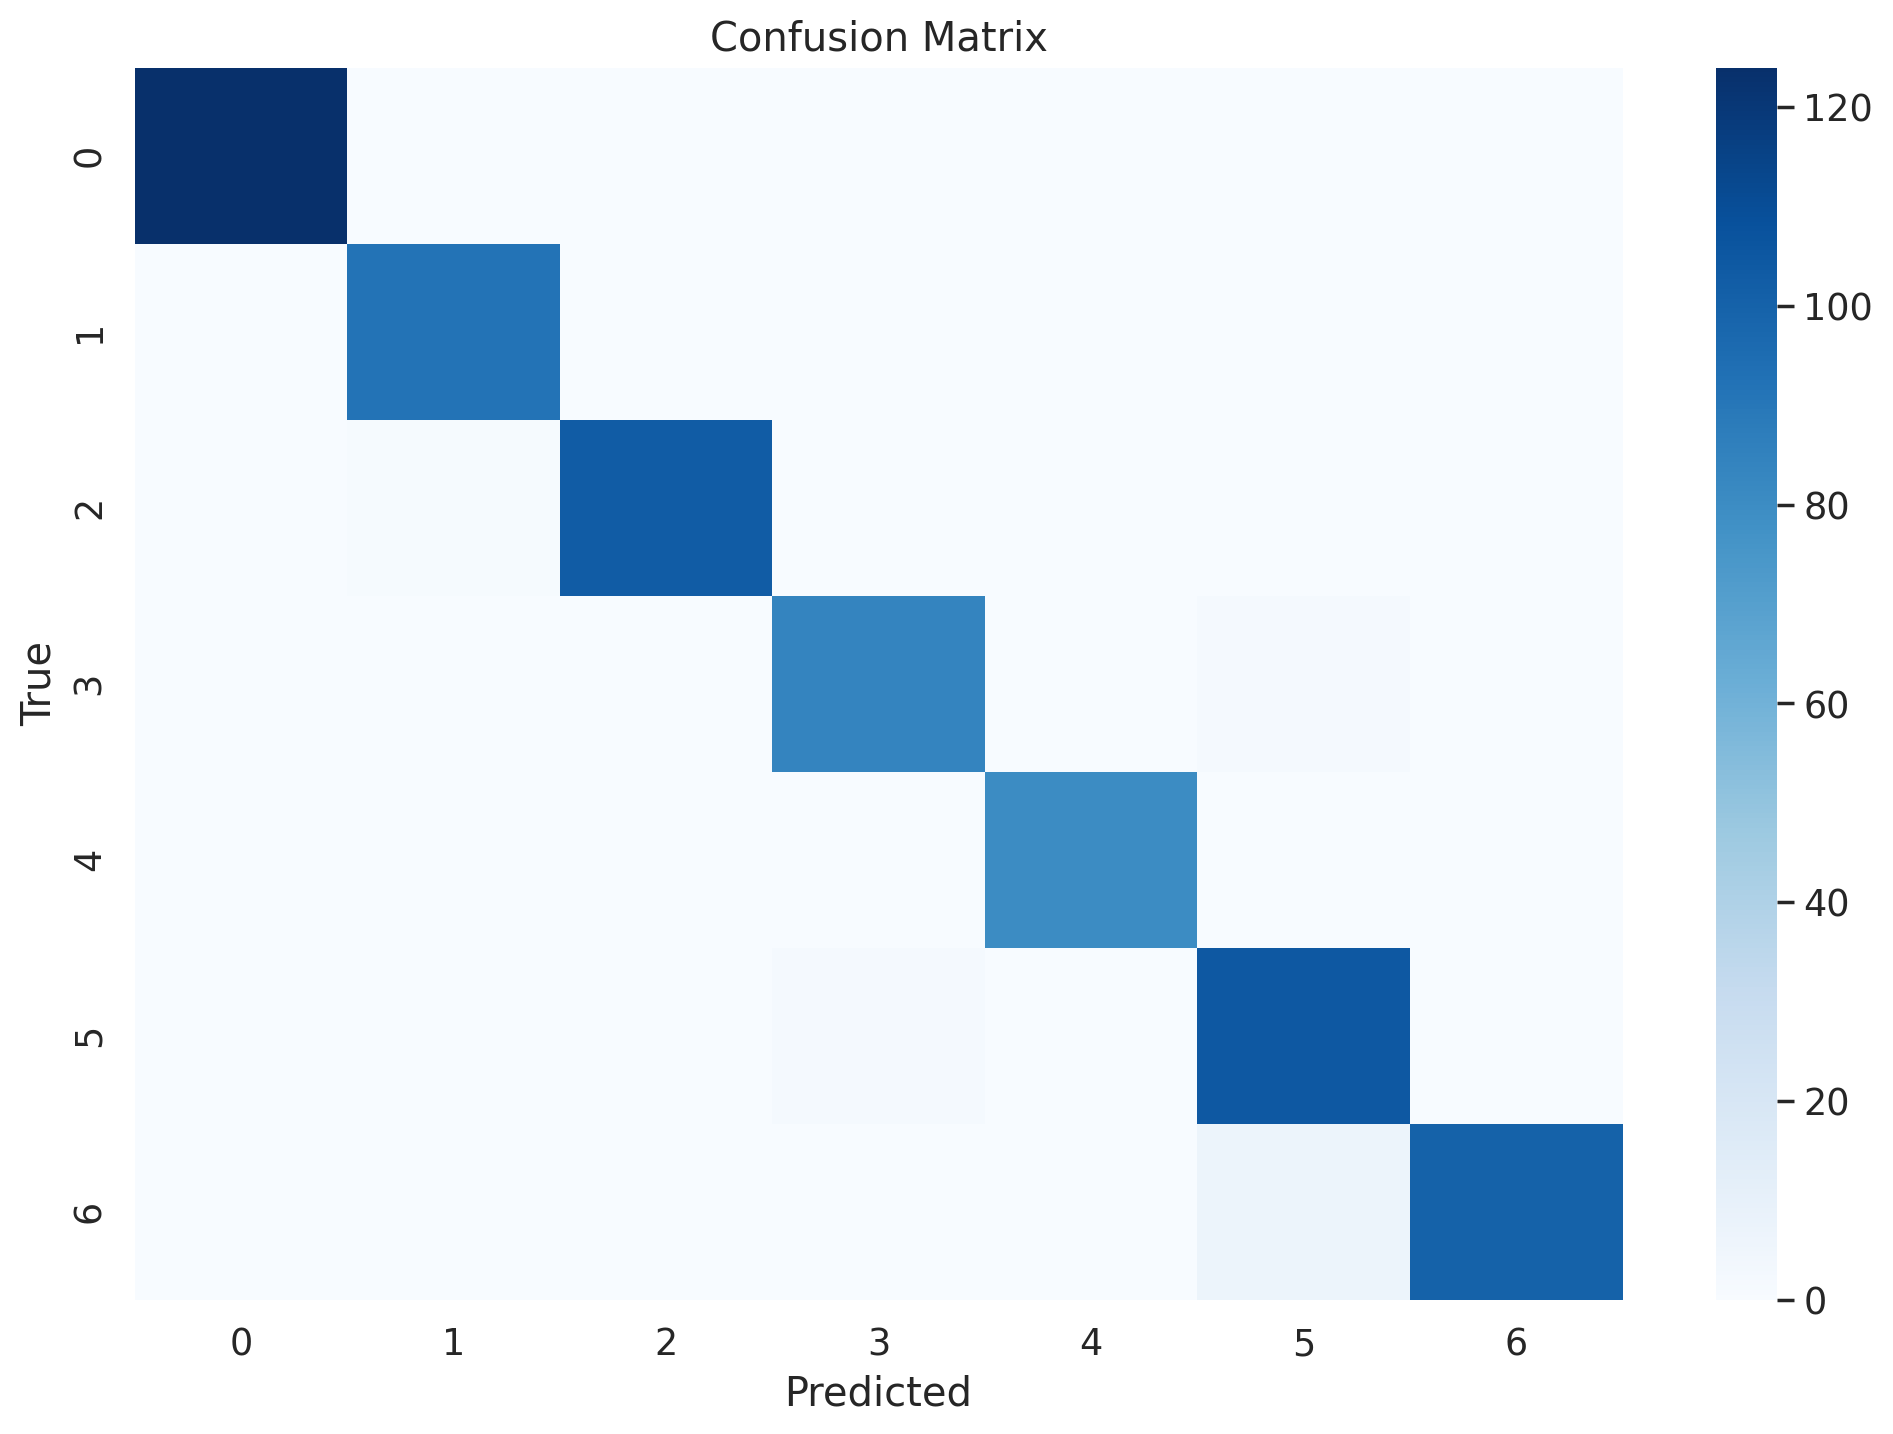

In [10]:
# ===== Load best (optional) =====
model = AutoModelForSequenceClassification.from_pretrained('checkpoint').to(device)

# ===== Test evaluation =====
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        labels = batch['labels']
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

report = classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(num_labels)])
print(report)
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# ===== Optional: Confusion matrix heatmap =====
plt.figure()
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()